In [7]:
# ==============================================================================
# PROYECTO FINAL: PREDICCIÓN DE GENERACIÓN ELÉCTRICA EN PANAMÁ CON PROPHET
# ==============================================================================

# IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings de versiones de pandas/prophet

# Configuración de estilo visual para todos los gráficos del cuaderno
sns.set_style('whitegrid')


In [10]:
# ------------------------------------------------------------------------------
# 2.1 Dataset original (formato ancho: Año, Distribuidor, Enero...Diciembre)
# ------------------------------------------------------------------------------

ruta_csv = "dataset.csv"
df_raw = pd.read_csv(ruta_csv)


# ------------------------------------------------------------------------------
# 2.2 Mapeo cualitativo -> cuantitativo (Label Encoding manual de 'Distribuidor')
#     Cada distribuidora se convierte en un código numérico para poder usarse
#     en cálculos de correlación y como regresor del modelo Prophet.
# ------------------------------------------------------------------------------
distribuidor_map = {"EDEMET": 0, "EDECHI": 1, "ENSA": 2}
df_raw["Distribuidor_Num"] = df_raw["Distribuidor"].map(distribuidor_map)

print("Mapeo aplicado a 'Distribuidor':", distribuidor_map)
df_raw.head(10)


Mapeo aplicado a 'Distribuidor': {'EDEMET': 0, 'EDECHI': 1, 'ENSA': 2}


,Año,Distribuidor,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,Distribuidor_Num
0,2019,EDECHI,269655.51,256111.47,245287.47,198890.86,277119.82,294115.28,310180.86,293662.95,246051.27,236229.27,300397.60,265211.91,1
1,2020,EDECHI,259934.93,292662.97,289679.97,245022.92,227402.84,236602.84,410898.91,396504.34,381292.17,389398.48,450949.57,433061.43,1
2,2021,EDECHI,351365.87,296337.24,296337.24,398683.14,499795.74,476730.85,462257.86,500228.50,450684.94,447860.37,364470.73,338649.65,1
3,2022,EDECHI,70036.38,69046.69,73343.76,74585.90,72168.86,70124.81,69688.01,69000.91,72430.85,71336.29,69431.01,70540.87,1
4,2023,EDECHI,182925.20,190387.16,250490.98,237966.43,223316.66,307568.41,247321.58,256409.77,324817.05,0.00,0.00,0.00,1
5,2024,EDECHI,281777.00,225295.00,282710.00,165091.00,240678.00,356741.00,458758.00,468359.00,415090.00,432107.00,508447.00,511931.00,1
6,2025,EDECHI,391742.86,344876.79,250442.28,274154.40,399511.26,354898.32,431796.19,407657.35,329037.25,361207.73,313795.54,346431.15,1
7,2019,EDEMET,583120.66,556931.67,541777.31,610242.75,555436.90,238002.61,461019.91,458425.04,491282.69,475111.69,458208.93,537100.44,0
8,2020,EDEMET,654987.15,638584.89,635137.89,655767.53,677320.43,677820.43,388790.41,428306.38,430345.87,466963.29,418847.39,504093.61,0
9,2021,EDEMET,398296.32,448254.03,444991.37,454356.95,392078.37,352867.34,430009.78,407756.69,456860.50,546621.88,503068.63,536183.31,0


In [11]:
# ------------------------------------------------------------------------------
# 3.1 Función de reestructuración con .melt() + .pivot_table()
# ------------------------------------------------------------------------------

orden_meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
               "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

def tabla_meses_por_anio(df, distribuidor):
    """Genera, para una distribuidora dada, una tabla con los meses en las filas
    (ordenados cronológicamente) y los años en las columnas."""
    df_dist = df[df["Distribuidor"] == distribuidor]

    # De formato ancho (meses en columnas) a formato largo con melt()
    df_largo = df_dist.melt(
        id_vars=["Año"],
        value_vars=orden_meses,
        var_name="Mes",
        value_name="Generación (MWh)"
    )

    # Pivot: meses en filas, años en columnas
    tabla = df_largo.pivot_table(
        index="Mes",
        columns="Año",
        values="Generación (MWh)"
    )

    # Reordenar filas cronológicamente (Enero -> Diciembre)
    tabla = tabla.reindex(orden_meses)

    return tabla

for distribuidora in df_raw["Distribuidor"].unique():
    print(f"\n================ TABLA REESTRUCTURADA: {distribuidora} (Meses x Años) ================")
    tabla = tabla_meses_por_anio(df_raw, distribuidora)
    print(tabla.round(2))



================ TABLA REESTRUCTURADA: EDECHI (Meses x Años) ================
Año              2019       2020       2021      2022       2023      2024  \
Mes                                                                          
Enero       269655.51  259934.93  351365.87  70036.38  182925.20  281777.0   
Febrero     256111.47  292662.97  296337.24  69046.69  190387.16  225295.0   
Marzo       245287.47  289679.97  296337.24  73343.76  250490.98  282710.0   
Abril       198890.86  245022.92  398683.14  74585.90  237966.43  165091.0   
Mayo        277119.82  227402.84  499795.74  72168.86  223316.66  240678.0   
Junio       294115.28  236602.84  476730.85  70124.81  307568.41  356741.0   
Julio       310180.86  410898.91  462257.86  69688.01  247321.58  458758.0   
Agosto      293662.95  396504.34  500228.50  69000.91  256409.77  468359.0   
Septiembre  246051.27  381292.17  450684.94  72430.85  324817.05  415090.0   
Octubre     236229.27  389398.48  447860.37  71336.29       0.0

In [12]:
# ------------------------------------------------------------------------------
# 3.2 Aislar variables cuantitativas y calcular matriz de correlación
# ------------------------------------------------------------------------------

columnas_cuantitativas = ["Año", "Distribuidor_Num"] + orden_meses
df_cuantitativo = df_raw[columnas_cuantitativas]

correlation_matrix = df_cuantitativo.corr()
correlation_matrix


,Año,Distribuidor_Num,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
Año,1.000000e+00,-9.880777e-15,0.124278,0.093298,0.144613,0.119290,0.164420,0.297016,0.267042,0.257634,0.278850,0.097691,0.044815,0.014444
Distribuidor_Num,-9.880777e-15,1.000000e+00,-0.659209,-0.656422,-0.554918,-0.473955,-0.528907,-0.568450,-0.612336,-0.561575,-0.672700,-0.584506,-0.568249,-0.528704
Enero,1.242777e-01,-6.592092e-01,1.000000,0.966294,0.936851,0.906823,0.958821,0.826204,0.831742,0.848626,0.829940,0.681134,0.607993,0.651792
Febrero,9.329843e-02,-6.564218e-01,0.966294,1.000000,0.963138,0.935950,0.930316,0.799902,0.784044,0.803537,0.844039,0.665765,0.614153,0.680110
Marzo,1.446126e-01,-5.549184e-01,0.936851,0.963138,1.000000,0.962618,0.928899,0.797202,0.756403,0.796027,0.830492,0.584323,0.533491,0.602425
Abril,1.192905e-01,-4.739552e-01,0.906823,0.935950,0.962618,1.000000,0.951193,0.740221,0.678710,0.736633,0.783239,0.548153,0.449687,0.539904
Mayo,1.644198e-01,-5.289070e-01,0.958821,0.930316,0.928899,0.951193,1.000000,0.848368,0.780114,0.829212,0.814746,0.588430,0.482055,0.539973
Junio,2.970164e-01,-5.684502e-01,0.826204,0.799902,0.797202,0.740221,0.848368,1.000000,0.775954,0.811730,0.793665,0.589727,0.535143,0.535851
Julio,2.670421e-01,-6.123359e-01,0.831742,0.784044,0.756403,0.678710,0.780114,0.775954,1.000000,0.984845,0.908752,0.786628,0.770918,0.744003
Agosto,2.576345e-01,-5.615752e-01,0.848626,0.803537,0.796027,0.736633,0.829212,0.811730,0.984845,1.000000,0.925968,0.769333,0.741429,0.732051


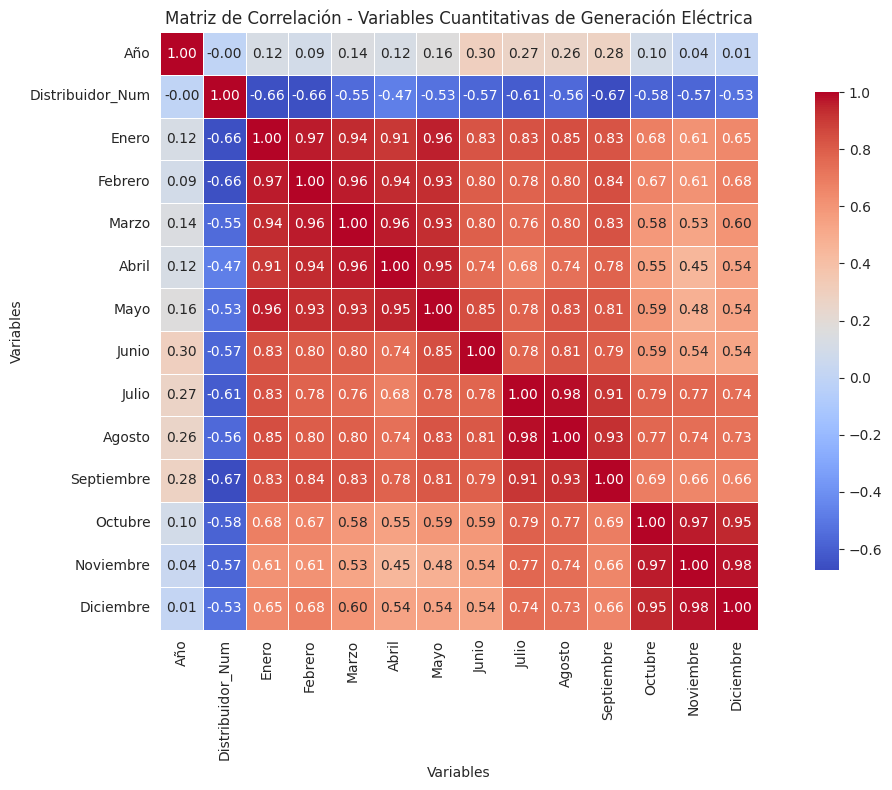

In [13]:
# ------------------------------------------------------------------------------
# Heatmap de correlación entre las variables cuantitativas
# ------------------------------------------------------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de Correlación - Variables Cuantitativas de Generación Eléctrica")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


In [14]:
# ------------------------------------------------------------------------------
# 4.1 Preparación de datos en formato largo (ds, y) + regresor Distribuidor_Num
# ------------------------------------------------------------------------------

meses_map = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4, "Mayo": 5, "Junio": 6,
    "Julio": 7, "Agosto": 8, "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}

def preparar_datos(df):
    """Convierte el formato ancho a largo y prepara los datos para Prophet.

    Nota: aquí SÍ necesitamos el formato vertical (ds, y), a diferencia de las tablas
    del EDA (meses en filas, años en columnas), porque Prophet modela cada observación
    mensual como un punto individual de una serie de tiempo, no como una matriz.
    Conservamos 'Distribuidor_Num' para poder usarlo como regresor externo (add_regressor).
    """
    # 1. Melt: pasar meses de columnas a filas
    df_melted = df.melt(
        id_vars=["Año", "Distribuidor", "Distribuidor_Num"],
        var_name="Mes_Str",
        value_name="y"
    )

    # 2. Construir la fecha ds a partir de Año y Mes
    df_melted["Mes"] = df_melted["Mes_Str"].map(meses_map)
    df_melted["ds"] = pd.to_datetime(
        df_melted["Año"].astype(str) + "-" + df_melted["Mes"].astype(str) + "-01"
    )

    # Agrupación asegurando sumarizaciones por fecha, distribuidor y su código numérico
    df_grouped = df_melted.groupby(
        ["Distribuidor", "Distribuidor_Num", "ds"]
    )["y"].sum().reset_index()

    # 3. Manejo de anomalías severas
    # Estrategia: Prophet maneja las ausencias de datos interpolando según la tendencia general.
    # Convertimos los ceros de 2023 y la caída anómala extrema de EDECHI en 2022 a NaN.

    # Valores 0.0 a finales de 2023
    df_grouped.loc[df_grouped["y"] == 0.0, "y"] = np.nan

    # Anomalía EDECHI 2022 (valores inusualmente bajos, < 100k)
    mask_edechi_2022 = (df_grouped["Distribuidor"] == "EDECHI") & (df_grouped["ds"].dt.year == 2022)
    df_grouped.loc[mask_edechi_2022, "y"] = np.nan

    return df_grouped[["Distribuidor", "Distribuidor_Num", "ds", "y"]].sort_values(
        ["Distribuidor", "ds"]
    ).reset_index(drop=True)

df_limpio = preparar_datos(df_raw)
df_limpio.head(10)


,Distribuidor,Distribuidor_Num,ds,y
0,EDECHI,1,2019-01-01,269655.51
1,EDECHI,1,2019-02-01,256111.47
2,EDECHI,1,2019-03-01,245287.47
3,EDECHI,1,2019-04-01,198890.86
4,EDECHI,1,2019-05-01,277119.82
5,EDECHI,1,2019-06-01,294115.28
6,EDECHI,1,2019-07-01,310180.86
7,EDECHI,1,2019-08-01,293662.95
8,EDECHI,1,2019-09-01,246051.27
9,EDECHI,1,2019-10-01,236229.27


In [15]:
# ------------------------------------------------------------------------------
# 5.1 Validación con conjunto de prueba 2025, incluyendo el regresor Distribuidor_Num
# ------------------------------------------------------------------------------

def validacion_modelos(df_completo):
    """Separa 2019-2024 para entrenamiento, 2025 para prueba y calcula MAE/RMSE/MAPE.
    Además arma un DataFrame con los valores reales y predichos del año de prueba,
    mes a mes por distribuidora, para poder graficarlos después."""
    distribuidoras = df_completo["Distribuidor"].unique()
    print("================ RESULTADOS DE VALIDACIÓN (AÑO DE PRUEBA: 2025) ================\n")

    filas_resultado = []

    for dist in distribuidoras:
        df_dist = df_completo[df_completo["Distribuidor"] == dist]

        # Split Train/Test
        train = df_dist[df_dist["ds"].dt.year <= 2024]
        test = df_dist[df_dist["ds"].dt.year == 2025]

        # Instanciar Prophet y agregar el regresor ANTES de entrenar (.fit())
        # Se activa la estacionalidad anual y se configura changepoint_prior_scale para permitir adaptabilidad
        modelo = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.05, seasonality_mode='additive')
        modelo.add_regressor('Distribuidor_Num')
        modelo.fit(train[['ds', 'y', 'Distribuidor_Num']])

        # Predicción (el regresor también debe estar presente en el dataframe futuro)
        prediccion = modelo.predict(test[['ds', 'Distribuidor_Num']])

        # Cálculo de métricas
        y_true = test['y'].values
        y_pred = prediccion['yhat'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        print(f"--- DISTRIBUIDORA: {dist} ---")
        print(f"  MAE  (Error Absoluto Medio):          {mae:,.2f} MWh  -> desviación promedio respecto al valor real")
        print(f"  RMSE (Raíz Error Cuadrático Medio):    {rmse:,.2f} MWh  -> penaliza más los meses con errores grandes")
        print(f"  MAPE (Error Porcentual Absoluto):      {mape:.2f}%     -> error relativo, comparable entre distribuidoras\n")

        # Guardamos, mes a mes, el valor real y el predicho para poder graficarlos después
        filas_resultado.append(pd.DataFrame({
            "Distribuidor": dist,
            "Mes": test["ds"].values,
            "MWh": y_true,
            "y_pred": y_pred
        }))

    return pd.concat(filas_resultado, ignore_index=True)

# Ejecutamos la validación: imprime las métricas y devuelve los valores real/predicho
resultados_test = validacion_modelos(df_limpio)


================ RESULTADOS DE VALIDACIÓN (AÑO DE PRUEBA: 2025) ================



INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


--- DISTRIBUIDORA: EDECHI ---
  MAE  (Error Absoluto Medio):          52,066.39 MWh  -> desviación promedio respecto al valor real
  RMSE (Raíz Error Cuadrático Medio):    63,963.09 MWh  -> penaliza más los meses con errores grandes
  MAPE (Error Porcentual Absoluto):      15.24%     -> error relativo, comparable entre distribuidoras



INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


--- DISTRIBUIDORA: EDEMET ---
  MAE  (Error Absoluto Medio):          116,118.62 MWh  -> desviación promedio respecto al valor real
  RMSE (Raíz Error Cuadrático Medio):    136,831.73 MWh  -> penaliza más los meses con errores grandes
  MAPE (Error Porcentual Absoluto):      26.53%     -> error relativo, comparable entre distribuidoras

--- DISTRIBUIDORA: ENSA ---
  MAE  (Error Absoluto Medio):          81,806.76 MWh  -> desviación promedio respecto al valor real
  RMSE (Raíz Error Cuadrático Medio):    96,823.02 MWh  -> penaliza más los meses con errores grandes
  MAPE (Error Porcentual Absoluto):      27.52%     -> error relativo, comparable entre distribuidoras



In [16]:
# ------------------------------------------------------------------------------
# 6.1 Entrenamiento de modelos finales con toda la data histórica (2019-2025)
# ------------------------------------------------------------------------------

def entrenar_modelos_produccion(df_completo):
    """Entrena los modelos finales con toda la data histórica (2019-2025) para predecir 2026,
    incluyendo Distribuidor_Num como regresor adicional."""
    distribuidoras = df_completo["Distribuidor"].unique()
    modelos = {}
    codigos_distribuidor = {}  # Guardamos el código numérico de cada distribuidora para usarlo al predecir

    for dist in distribuidoras:
        df_dist = df_completo[df_completo["Distribuidor"] == dist]

        modelo = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.05)
        modelo.add_regressor('Distribuidor_Num')
        modelo.fit(df_dist[['ds', 'y', 'Distribuidor_Num']])

        modelos[dist] = modelo
        codigos_distribuidor[dist] = df_dist['Distribuidor_Num'].iloc[0]

    return modelos, codigos_distribuidor

# Entrenamos los modelos de producción
modelos_finales, codigos_distribuidor = entrenar_modelos_produccion(df_limpio)
print("Modelos entrenados para:", list(modelos_finales.keys()))
print("Códigos numéricos usados como regresor:", codigos_distribuidor)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Modelos entrenados para: ['EDECHI', 'EDEMET', 'ENSA']
Códigos numéricos usados como regresor: {'EDECHI': np.int64(1), 'EDEMET': np.int64(0), 'ENSA': np.int64(2)}


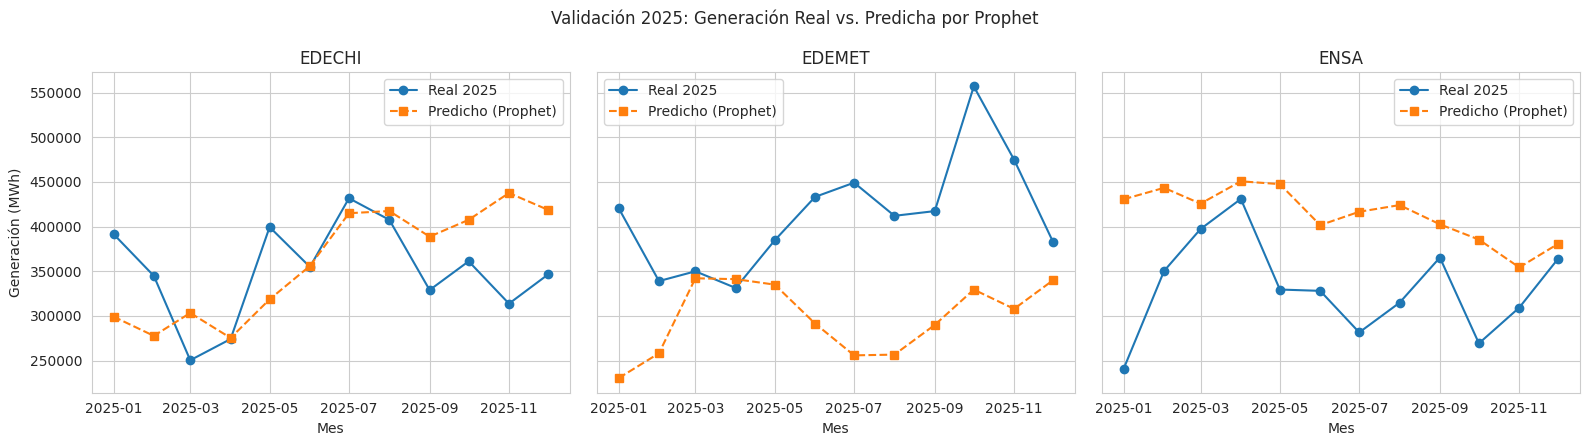

In [17]:
# ==============================================================================
# 7.1 Gráfica de validación: Real vs. Predicho por distribuidora (2025)
# ==============================================================================

distribuidoras_orden = resultados_test["Distribuidor"].unique()

fig, axes = plt.subplots(1, len(distribuidoras_orden), figsize=(16, 4.5), sharey=True)

for ax, dist_name in zip(axes, distribuidoras_orden):
    subset = resultados_test[resultados_test["Distribuidor"] == dist_name].sort_values("Mes")
    ax.plot(subset["Mes"], subset["MWh"], marker="o", label="Real 2025")
    ax.plot(subset["Mes"], subset["y_pred"], marker="s", linestyle="--", label="Predicho (Prophet)")
    ax.set_title(dist_name)
    ax.set_xlabel("Mes")
    ax.legend()

axes[0].set_ylabel("Generación (MWh)")
plt.suptitle("Validación 2025: Generación Real vs. Predicha por Prophet")
plt.tight_layout()
plt.savefig("validacion_real_vs_predicho.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
def menu_interactivo(modelos_finales, codigos_distribuidor):
    """
    Despliega un menú interactivo por consola para consultar las predicciones
    de generación eléctrica en Panamá para el año 2026.
    """
    while True:
        print("\n========================================================")
        print("   SISTEMA EXPERTO DE PREDICCIÓN ELÉCTRICA (PANAMÁ 2026) ")
        print("========================================================")
        print("1. Consultar una Distribuidora y Mes específico")
        print("2. Consultar Consolidado Nacional Anual 2026")
        print("3. Salir del sistema")
        print("--------------------------------------------------------")

        opcion = input("Seleccione una opción (1-3): ").strip()

        if opcion == "1":
            print("\nDistribuidoras disponibles:", list(modelos_finales.keys()))
            dist = input("Ingrese el nombre de la distribuidora: ").strip().upper()

            if dist not in modelos_finales:
                print(f"Error: '{dist}' no es una distribuidora válida.")
                continue

            mes = input("Ingrese el mes a consultar (ej. Enero, Mayo, Diciembre): ").strip().capitalize()
            if mes not in meses_map:
                print(f"Error: '{mes}' no es un mes válido.")
                continue

            # Realizar la predicción individual
            mes_num = meses_map[mes]
            fecha_consulta = pd.DataFrame({'ds': [pd.to_datetime(f"2026-{mes_num}-01")]})
            fecha_consulta['Distribuidor_Num'] = codigos_distribuidor[dist]

            prediccion = modelos_finales[dist].predict(fecha_consulta)
            valor_estimado = prediccion['yhat'].values[0]

            print(f"\n📢 [RESULTADO] {dist} en {mes} 2026: {valor_estimado:,.2f} MWh")

        elif opcion == "2":
            print("\nCalculando Consolidado Nacional Anual 2026...")
            total_nacional = 0
            for dist, mod in modelos_finales.items():
                fechas_2026 = pd.DataFrame({'ds': pd.date_range(start='2026-01-01', end='2026-12-01', freq='MS')})
                fechas_2026['Distribuidor_Num'] = codigos_distribuidor[dist]
                pred = mod.predict(fechas_2026)
                suma_anual = pred['yhat'].sum()
                total_nacional += suma_anual
                print(f"    - Aporte anual estimado {dist}: {suma_anual:,.2f} MWh")
            print(f"    >>> GENERACIÓN TOTAL NACIONAL ESTIMADA 2026: {total_nacional:,.2f} MWh")

        elif opcion == "3":
            print("\nSaliendo del sistema experto. ¡Hasta luego!")
            break
        else:
            print(" Opción inválida. Por favor, intente de nuevo.")

In [21]:
# ------------------------------------------------------------------------------
# Ejecutar el menú interactivo (requiere input() por consola)
# ------------------------------------------------------------------------------
# NOTA: input() bloquea la ejecución automática de 'Run All' / nbconvert / CI.
# Para usar el sistema experto de forma interactiva en Jupyter local, descomenta:
# menu_interactivo(modelos_finales, codigos_distribuidor)

# Demostración NO interactiva (evidencia de ejecución reproducible sin input()):
print("Demostración funcional del sistema (modo no interactivo):\n")

ejemplo_dist = "EDECHI"
ejemplo_mes = "Mayo"
mes_num = meses_map[ejemplo_mes]
fecha_consulta = pd.DataFrame({'ds': [pd.to_datetime(f"2026-{mes_num}-01")]})
fecha_consulta['Distribuidor_Num'] = codigos_distribuidor[ejemplo_dist]
prediccion = modelos_finales[ejemplo_dist].predict(fecha_consulta)
valor_estimado = prediccion['yhat'].values[0]
print(f"[Opción 1] {ejemplo_dist} - {ejemplo_mes} 2026: {valor_estimado:,.2f} MWh\n")

print("[Opción 2] Consolidado Nacional Anual 2026:")
total_nacional = 0
for dist, mod in modelos_finales.items():
    fechas_2026 = pd.DataFrame({'ds': pd.date_range(start='2026-01-01', end='2026-12-01', freq='MS')})
    fechas_2026['Distribuidor_Num'] = codigos_distribuidor[dist]
    pred = mod.predict(fechas_2026)
    suma_anual = pred['yhat'].sum()
    total_nacional += suma_anual
    print(f"    - Aporte anual estimado {dist}: {suma_anual:,.2f} MWh")
print(f"    >>> GENERACIÓN TOTAL NACIONAL ESTIMADA 2026: {total_nacional:,.2f} MWh")

# Para la demo interactiva completa por consola, descomenta la línea de abajo:

#menu_interactivo(modelos_finales, codigos_distribuidor)


Demostración funcional del sistema (modo no interactivo):

[Opción 1] EDECHI - Mayo 2026: 341,767.95 MWh

[Opción 2] Consolidado Nacional Anual 2026:
    - Aporte anual estimado EDECHI: 4,352,874.03 MWh
    - Aporte anual estimado EDEMET: 4,688,693.80 MWh
    - Aporte anual estimado ENSA: 5,163,235.06 MWh
    >>> GENERACIÓN TOTAL NACIONAL ESTIMADA 2026: 14,204,802.89 MWh


In [ ]:
# ------------------------------------------------------------------------------
# 9. Guardado de los modelos entrenados (para el entregable del proyecto)
# ------------------------------------------------------------------------------
import pickle, os

os.makedirs("../models", exist_ok=True)
for dist, modelo in modelos_finales.items():
    with open(f"../models/modelo_prophet_{dist}.pkl", "wb") as f:
        pickle.dump(modelo, f)

print("Modelos guardados en la carpeta 'models/':")
for dist in modelos_finales:
    print(f"  - modelo_prophet_{dist}.pkl")
